In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch # For legend

from scipy.stats import spearmanr
from scipy.spatial.distance import squareform




In [1]:
df = pd.read_csv('./DEG/merged_tpm_data_17.csv', index_col=0)

NameError: name 'pd' is not defined

Original data shape: (65861, 23)
Filtered data shape: (34475, 23)
Removed 31386 rows containing 'STRG'


/tmp/ipykernel_2958256/2175932381.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Sample', y='Expression',


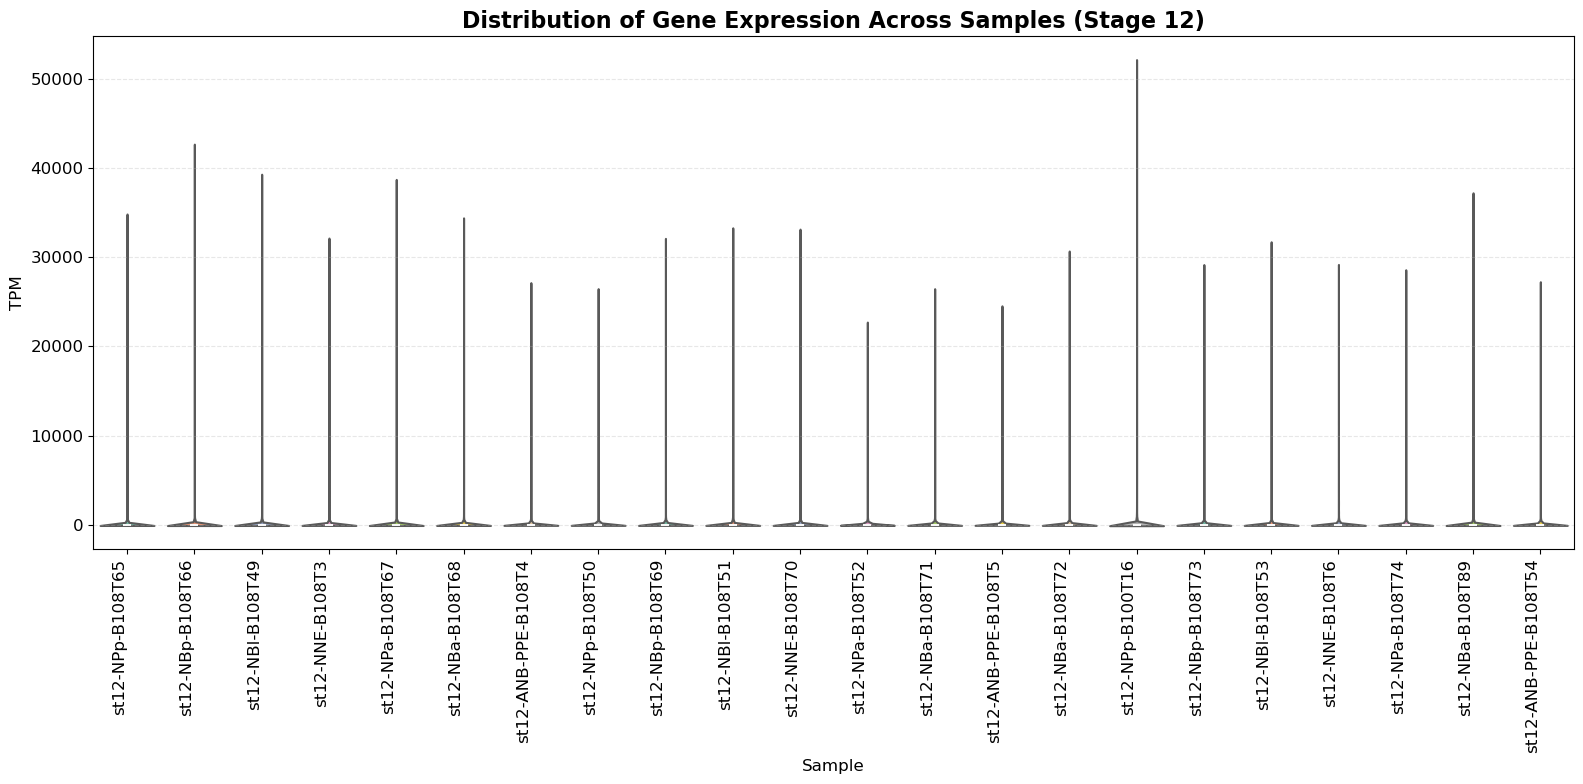

/tmp/ipykernel_2958256/2175932381.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Sample', y='log2(TPM + 1)',


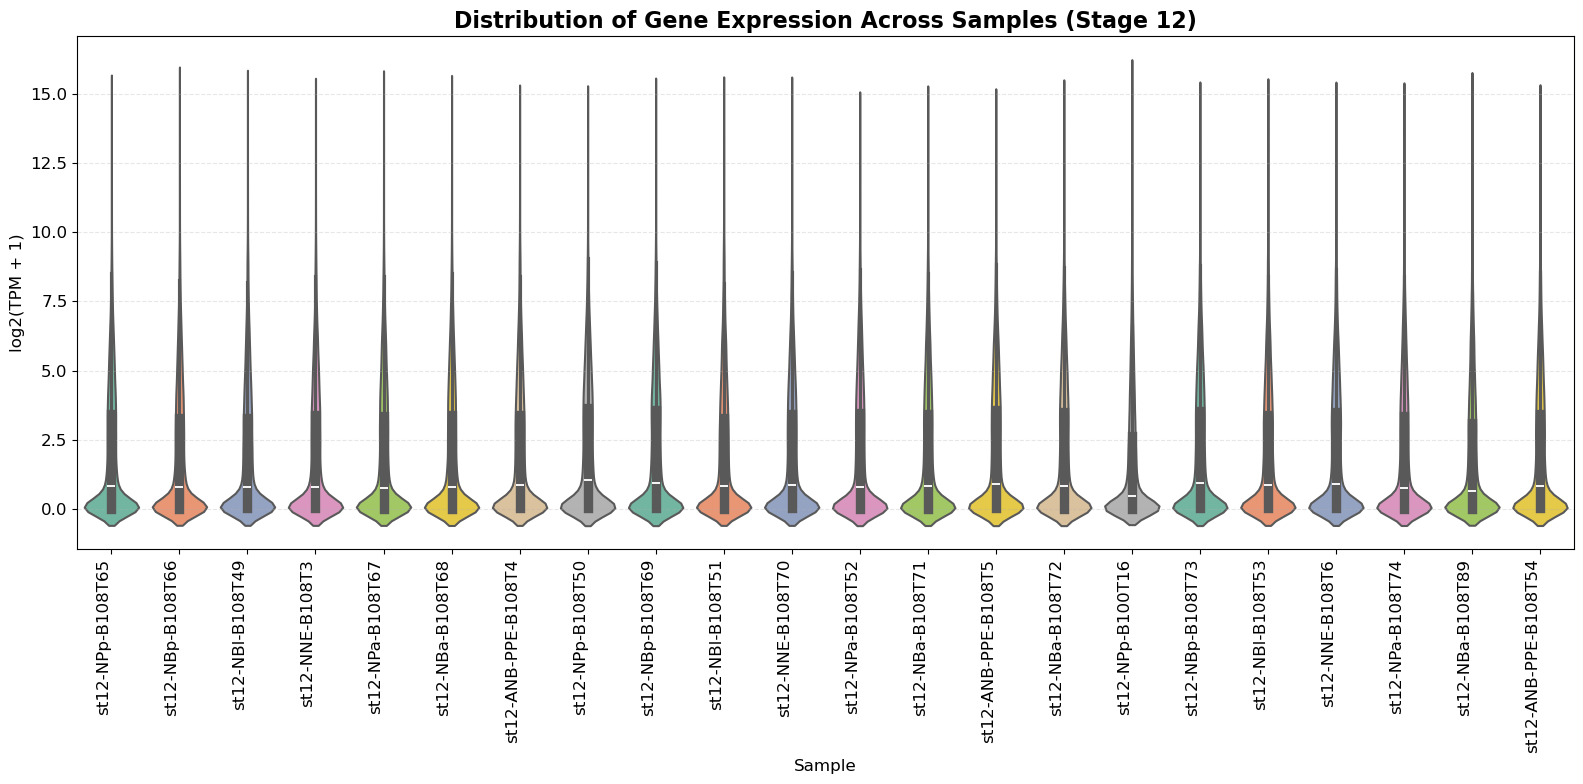

In [ ]:
#Raw data w/o filteration


# 2. 데이터 준비
df = pd.read_csv('./DEG/merged_tpm_data_12.csv')


# Remove rows where Gene ID contains 'STRG'
df_filtered = df[~df['GeneID'].str.contains('STRG', na=False)]

print(f"Original data shape: {df.shape}")
print(f"Filtered data shape: {df_filtered.shape}")
print(f"Removed {df.shape[0] - df_filtered.shape[0]} rows containing 'STRG'")

df_filtered = df_filtered.set_index('GeneID')
df_filtered = df_filtered.replace([np.inf, -np.inf], np.nan)
df_filtered = df_filtered.fillna(0)
df_filtered = df_filtered[(df_filtered > 0).any(axis=1)]
# Log2 transformation (add pseudocount to avoid log(0))
df_log = np.log2(df_filtered + 1)
# Reshape data for plotting (convert to long format)
df_long = df_filtered.melt(var_name='Sample', value_name='Expression')

# Create violin plot
plt.figure(figsize=(16, 8))
sns.violinplot(data=df_long, x='Sample', y='Expression', 
               palette='Set2', inner='box', linewidth=1.5)

plt.xticks(rotation=90, ha='right')
plt.title('Distribution of Gene Expression Across Samples (Stage 12)', fontsize=16, fontweight='bold')
plt.xlabel('Sample', fontsize=12)
plt.ylabel('TPM', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('violin_plot_samples_12_raw.png', dpi=300, bbox_inches='tight')
plt.show()

df_long = df_log.melt(var_name='Sample', value_name='log2(TPM + 1)')

# Create violin plot
plt.figure(figsize=(16, 8))
sns.violinplot(data=df_long, x='Sample', y='log2(TPM + 1)', 
               palette='Set2', inner='box', linewidth=1.5)

plt.xticks(rotation=90, ha='right')
plt.title('Distribution of Gene Expression Across Samples (Stage 12)', fontsize=16, fontweight='bold')
plt.xlabel('Sample', fontsize=12)
plt.ylabel('log2(TPM + 1)', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('violin_plot_samples_12_log.png', dpi=300, bbox_inches='tight')
plt.show()


Original data shape: (65861, 23)
Filtered data shape: (19013, 22)
Removed 46848 rows containing 'STRG'


/tmp/ipykernel_329660/1364738518.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Sample', y='Expression',


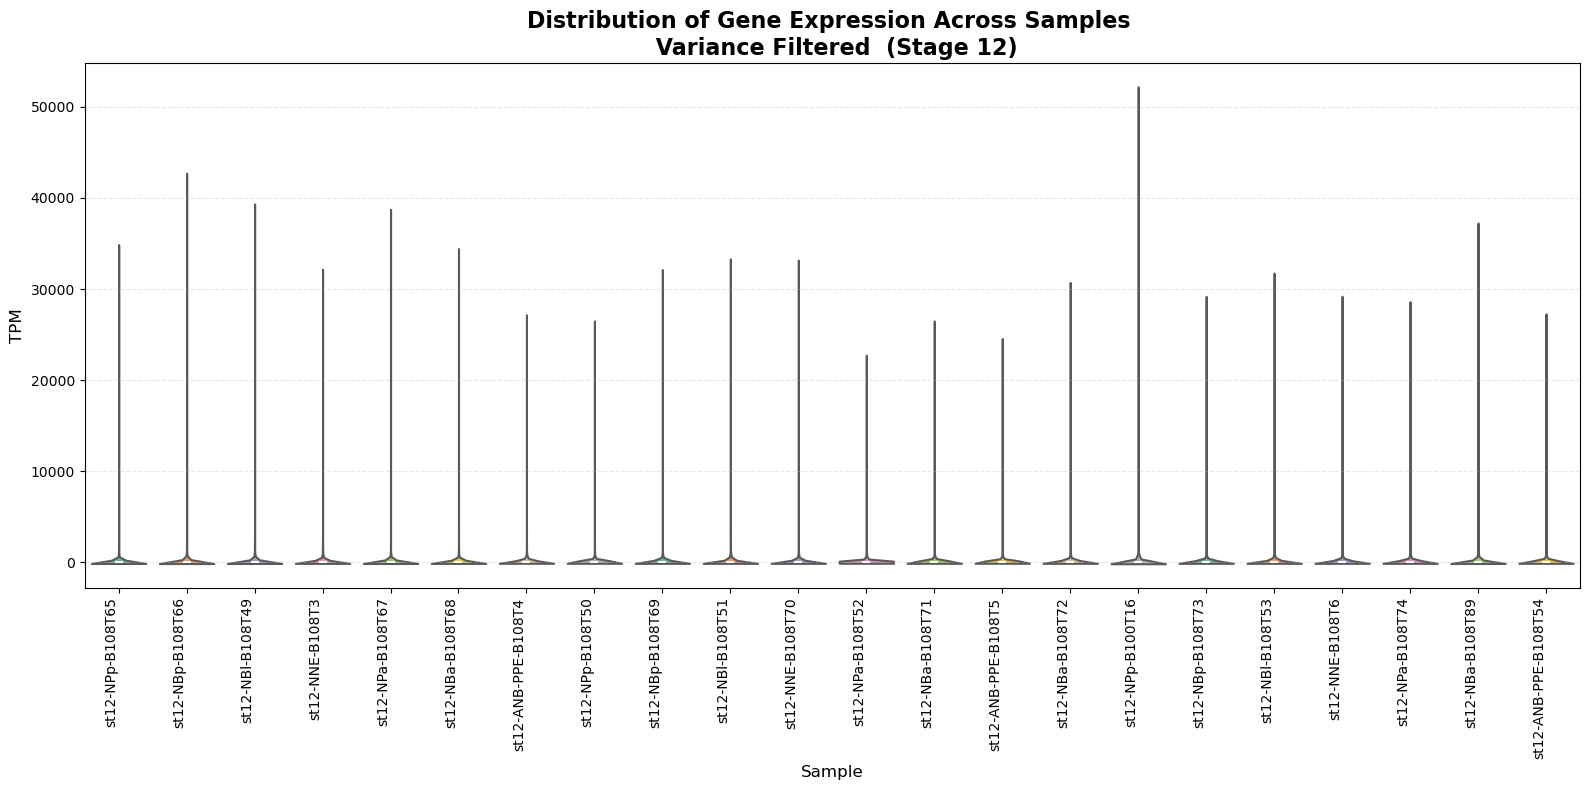

/tmp/ipykernel_329660/1364738518.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Sample', y='log2(TPM + 1)',


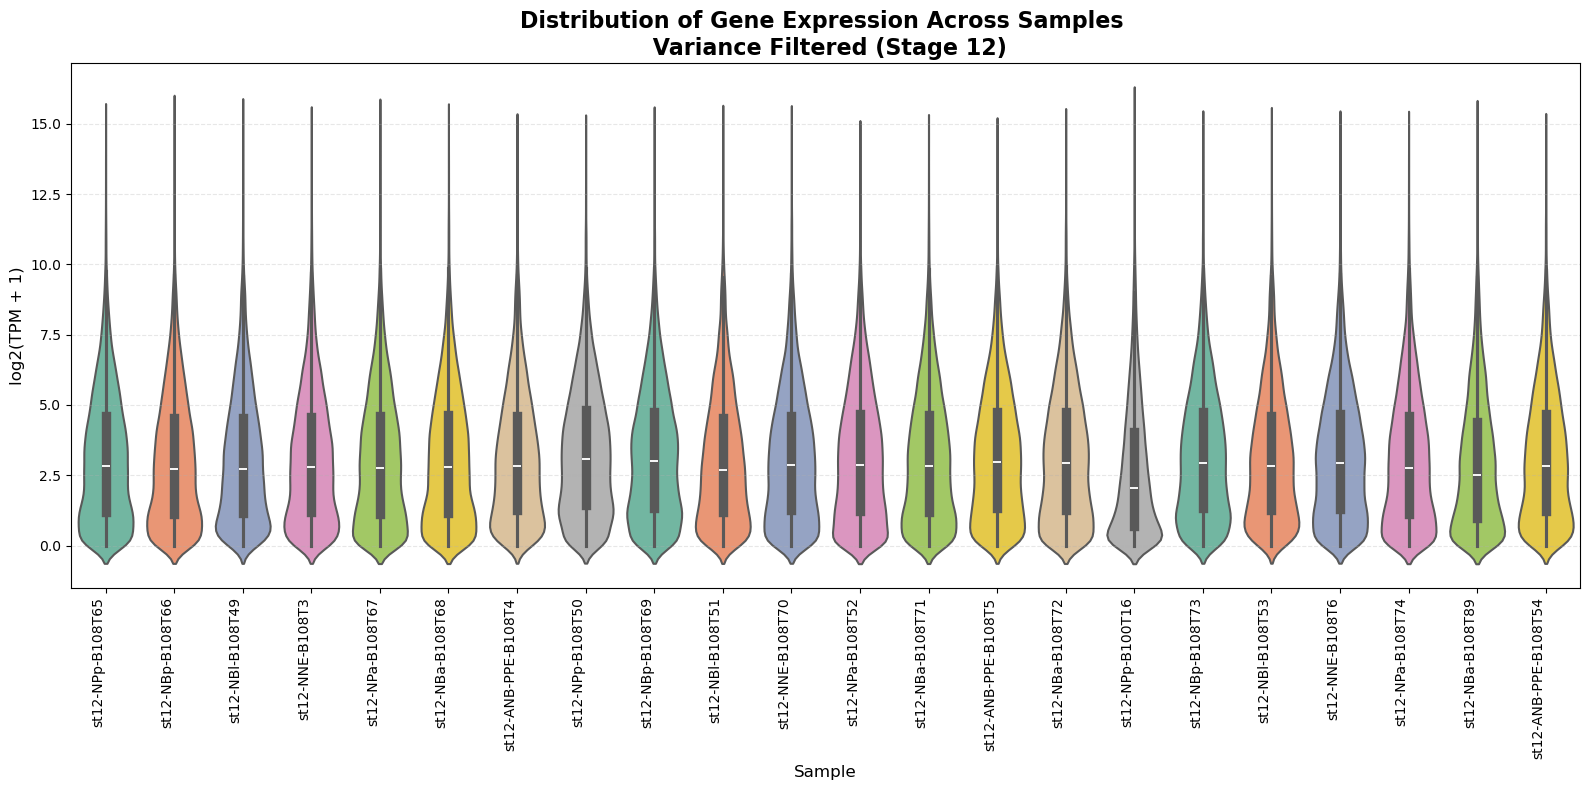

In [7]:
#Variance filter

# 2. 데이터 준비
df = pd.read_csv('./DEG/merged_tpm_data_12.csv')


# Remove rows where Gene ID contains 'STRG'
df_filtered = df[~df['GeneID'].str.contains('STRG', na=False)]
df_filtered = df_filtered.set_index('GeneID')
df_filtered = df_filtered.replace([np.inf, -np.inf], np.nan)
df_filtered = df_filtered.fillna(0)
df_filtered = df_filtered[(df_filtered > 1).any(axis=1)]
#gene_vars = df_filtered.var(axis=1)
#df_filtered = df_filtered[gene_vars > 0.01]
print(f"Original data shape: {df.shape}")
print(f"Filtered data shape: {df_filtered.shape}")
print(f"Removed {df.shape[0] - df_filtered.shape[0]} rows containing 'STRG'")


# Log2 transformation (add pseudocount to avoid log(0))
df_log = np.log2(df_filtered + 1)
# Reshape data for plotting (convert to long format)
df_long = df_filtered.melt(var_name='Sample', value_name='Expression')

# Create violin plot
plt.figure(figsize=(16, 8))
sns.violinplot(data=df_long, x='Sample', y='Expression', 
               palette='Set2', inner='box', linewidth=1.5)

plt.xticks(rotation=90, ha='right')
plt.title('Distribution of Gene Expression Across Samples \n Variance Filtered  (Stage 12)', fontsize=16, fontweight='bold')
plt.xlabel('Sample', fontsize=12)
plt.ylabel('TPM', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('violin_plot_samples_12_raw_VAR.png', dpi=300, bbox_inches='tight')
plt.show()

df_long = df_log.melt(var_name='Sample', value_name='log2(TPM + 1)')

# Create violin plot
plt.figure(figsize=(16, 8))
sns.violinplot(data=df_long, x='Sample', y='log2(TPM + 1)', 
               palette='Set2', inner='box', linewidth=1.5)

plt.xticks(rotation=90, ha='right')
plt.title('Distribution of Gene Expression Across Samples \n Variance Filtered (Stage 12)', fontsize=16, fontweight='bold')
plt.xlabel('Sample', fontsize=12)
plt.ylabel('log2(TPM + 1)', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('violin_plot_samples_12_log_VAR.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df1 =  pd.read_csv('./DEG/merged_tpm_data_12.csv')
df1 = df1[~df1['GeneID'].str.contains('STRG', na=False)]
df1 = df1.set_index('GeneID')
df2 = pd.read_csv('./DEG/merged_tpm_data_14.csv')
df2 = df2[~df2['GeneID'].str.contains('STRG', na=False)]
df2 = df2.set_index('GeneID')
df3 = pd.read_csv('./DEG/merged_tpm_data_17.csv')
df3 = df3[~df3['GeneID'].str.contains('STRG', na=False)]
df3 = df3.set_index('GeneID')
df_m = pd.concat([df1, df2,df3], axis=1, join='inner')

print(f"Original data shape: {df_m.shape}")
print(f"Filtered data shape: {df.shape}")
print(f"Removed {df_m.shape[0] - df.shape[0]} rows containing 'STRG'")


df = df_m.replace([np.inf, -np.inf], np.nan)
df = df.fillna(0)
df = df[(df > 0).any(axis=1)]

Original data shape: (34475, 63)
Filtered data shape: (65861, 23)
Removed -31386 rows containing 'STRG'


/tmp/ipykernel_2958256/550429815.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Sample', y='log2(TPM + 1)',


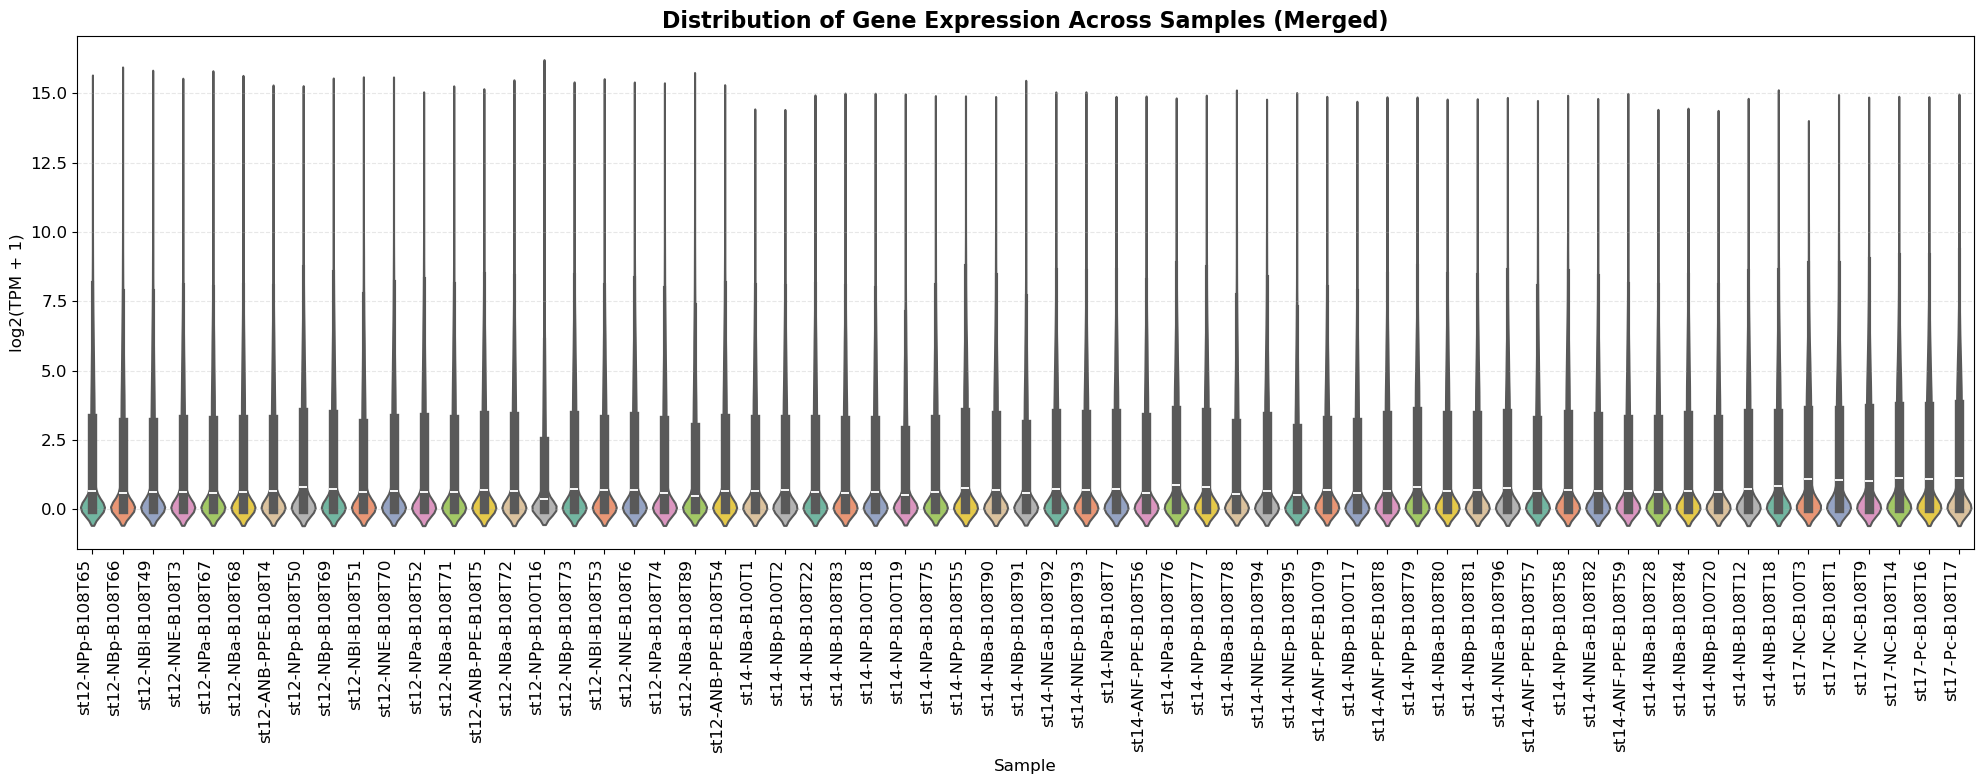

In [67]:


# Log2 transformation (add pseudocount to avoid log(0))
df_log = np.log2(df + 1)
df_long = df_log.melt(var_name='Sample', value_name='log2(TPM + 1)')

# Create violin plot
plt.figure(figsize=(20, 8))
sns.violinplot(data=df_long, x='Sample', y='log2(TPM + 1)', 
               palette='Set2', inner='box', linewidth=1.5)

plt.xticks(rotation=90, ha='right')
plt.title('Distribution of Gene Expression Across Samples (Merged)', fontsize=16, fontweight='bold')
plt.xlabel('Sample', fontsize=12)
plt.ylabel('log2(TPM + 1)', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('violin_plot_samples_merged_log.png', dpi=300, bbox_inches='tight')
plt.show()


Original genes: 32969
Filtered genes: 24437
Samples: 63


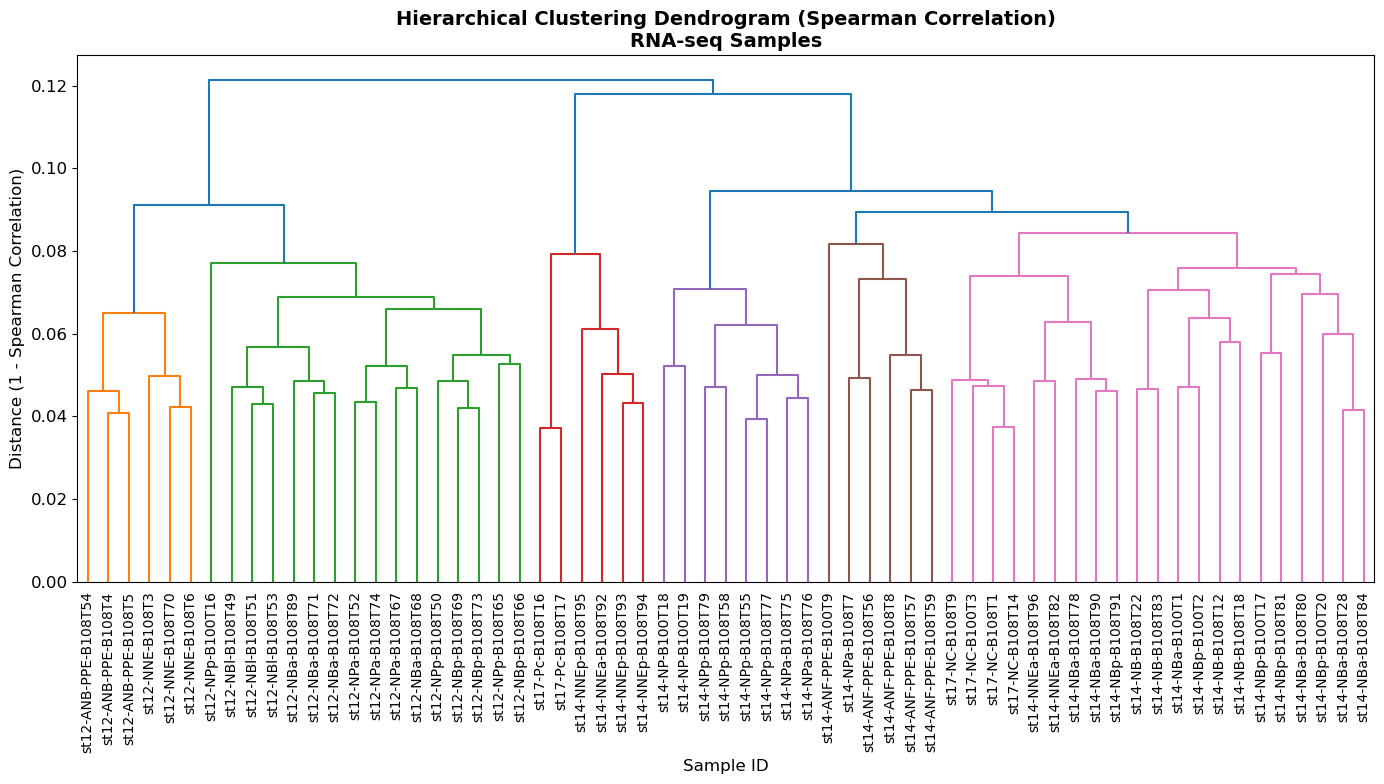

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

In [ ]:

# Remove genes with zero or near-zero variance to avoid correlation issues
gene_vars = df.var(axis=1)
df_filtered = df[gene_vars > 0.01]

print(f"Original genes: {len(df)}")
print(f"Filtered genes: {len(df_filtered)}")
print(f"Samples: {len(df_filtered.columns)}")

# Calculate Spearman correlation matrix between samples
corr_matrix, _ = spearmanr(df, axis=0)

# Convert correlation to distance (1 - correlation)
# This ensures higher correlation = smaller distance
distance_matrix = 1 - corr_matrix

# Ensure distance matrix is valid (no negative values due to floating point)
distance_matrix = np.clip(distance_matrix, 0, 2)

# Convert to condensed distance matrix for linkage
condensed_dist = squareform(distance_matrix, checks=False)

# Perform hierarchical clustering
# Methods: 'average', 'complete', 'single', 'ward' (ward requires Euclidean)
linkage_matrix = linkage(condensed_dist, method='average')

# Create the dendrogram
plt.figure(figsize=(14, 8))

dendrogram(
    linkage_matrix,
    labels=df_filtered.columns,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0.7 * max(linkage_matrix[:, 2])
)

plt.title('Hierarchical Clustering Dendrogram (Spearman Correlation)\nRNA-seq Samples', 
          fontsize=14, fontweight='bold')
plt.xlabel('Sample ID', fontsize=12)
plt.ylabel('Distance (1 - Spearman Correlation)', fontsize=12)
plt.tight_layout()
plt.savefig('spearman_dendrogram_merged.png', dpi=300, bbox_inches='tight')
plt.show()





Original data shape: (64293, 7)
Filtered data shape: (34475, 7)
Removed 29818 rows containing 'STRG'
Original genes: 30420
Filtered genes: 23240
Samples: 6


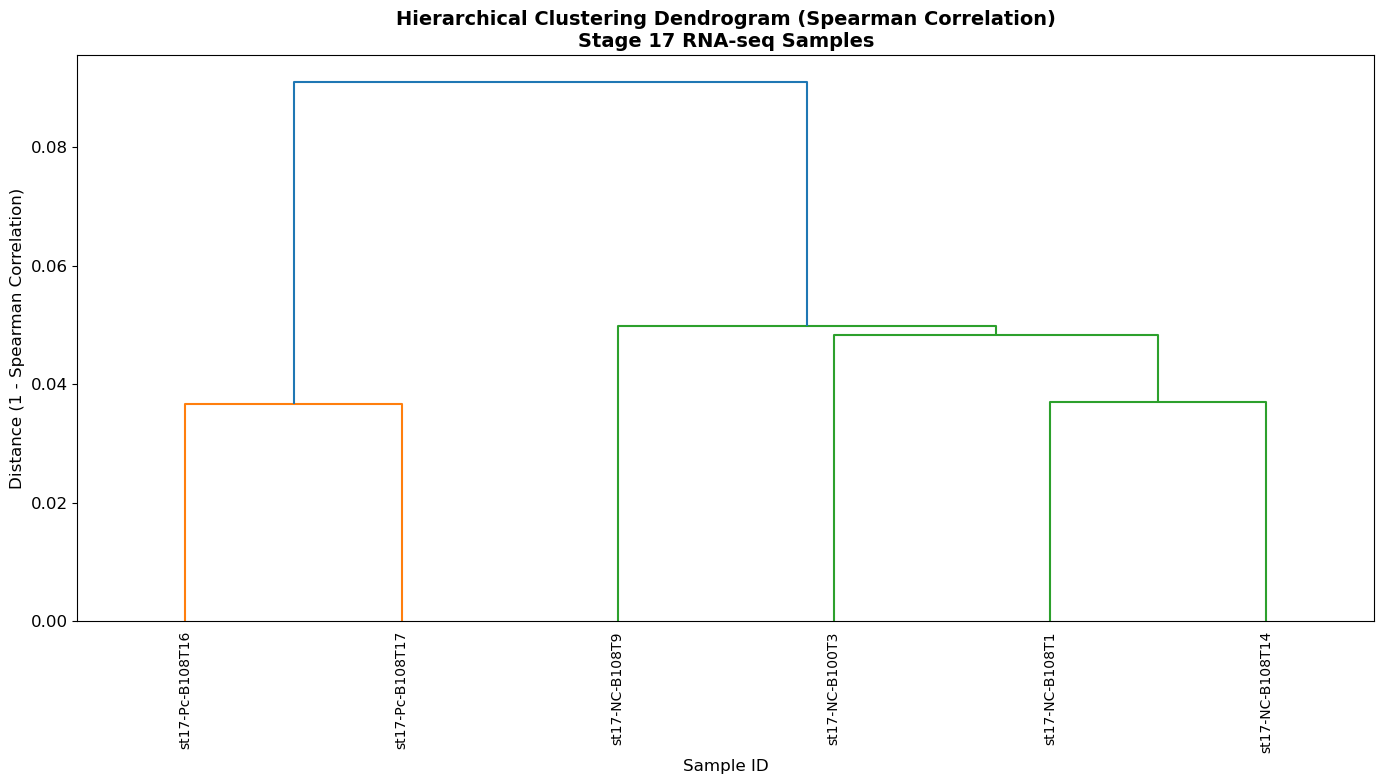

In [71]:
# 2. 데이터 준비
df = pd.read_csv('./DEG/merged_tpm_data_17.csv')


# Remove rows where Gene ID contains 'STRG'
df_filtered = df[~df['GeneID'].str.contains('STRG', na=False)]

print(f"Original data shape: {df.shape}")
print(f"Filtered data shape: {df_filtered.shape}")
print(f"Removed {df.shape[0] - df_filtered.shape[0]} rows containing 'STRG'")

df_filtered = df_filtered.set_index('GeneID')
df_filtered = df_filtered.replace([np.inf, -np.inf], np.nan)
df_filtered = df_filtered.fillna(0)
df = df_filtered[(df_filtered > 0).any(axis=1)]

gene_vars = df.var(axis=1)
df_filtered = df[gene_vars > 0.01]

print(f"Original genes: {len(df)}")
print(f"Filtered genes: {len(df_filtered)}")
print(f"Samples: {len(df_filtered.columns)}")

# Calculate Spearman correlation matrix between samples
corr_matrix, _ = spearmanr(df, axis=0)

# Convert correlation to distance (1 - correlation)
# This ensures higher correlation = smaller distance
distance_matrix = 1 - corr_matrix

# Ensure distance matrix is valid (no negative values due to floating point)
distance_matrix = np.clip(distance_matrix, 0, 2)

# Convert to condensed distance matrix for linkage
condensed_dist = squareform(distance_matrix, checks=False)

# Perform hierarchical clustering
# Methods: 'average', 'complete', 'single', 'ward' (ward requires Euclidean)
linkage_matrix = linkage(condensed_dist, method='average')

# Create the dendrogram
plt.figure(figsize=(14, 8))

dendrogram(
    linkage_matrix,
    labels=df_filtered.columns,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0.7 * max(linkage_matrix[:, 2])
)

plt.title('Hierarchical Clustering Dendrogram (Spearman Correlation)\nStage 17 RNA-seq Samples', 
          fontsize=14, fontweight='bold')
plt.xlabel('Sample ID', fontsize=12)
plt.ylabel('Distance (1 - Spearman Correlation)', fontsize=12)
plt.tight_layout()
plt.savefig('spearman_dendrogram_17.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Calculate correlation for heatmap (using filtered data)
sample_corr, _ = spearmanr(df_filtered, axis=0)

# Create clustermap
g = sns.clustermap(
    sample_corr,
    method='average',
    metric='correlation',
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    xticklabels=df_filtered.columns,
    yticklabels=df_filtered.columns,
    figsize=(12, 10),
    cbar_kws={'label': 'Spearman Correlation'}
)

g.ax_heatmap.set_xlabel('Samples', fontsize=12)
g.ax_heatmap.set_ylabel('Samples', fontsize=12)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)

plt.suptitle('Sample Correlation Heatmap with Hierarchical Clustering', 
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig('spearman_clustermap_merged_nofilter.png', dpi=300, bbox_inches='tight')
plt.show()

# Print clustering information
print("\n=== Clustering Summary ===")
print(f"Linkage method: average")
print(f"Distance metric: 1 - Spearman correlation")
print(f"\nSample correlation range: [{sample_corr.min():.3f}, {sample_corr.max():.3f}]")
print(f"Distance range: [{distance_matrix.min():.3f}, {distance_matrix.max():.3f}]")

=== DATA DIAGNOSTICS ===
Shape: (64293, 63)

Data types:
float64    63
Name: count, dtype: int64

First few rows:
                  st12-NPp-B108T65  st12-NBp-B108T66  st12-NBl-B108T49  \
GeneID:108704861          0.000000          0.000000          0.000000   
GeneID:108704873          0.000000          0.000000          0.000000   
GeneID:444335            10.012642          5.267445          9.341256   
STRG.1                   10.222782          5.267445          9.357466   
GeneID:414604           146.202866        125.369240        166.140182   

                  st12-NNE-B108T3  st12-NPa-B108T67  st12-NBa-B108T68  \
GeneID:108704861         0.002647          0.000000          0.000000   
GeneID:108704873         0.000000          0.000000          0.000000   
GeneID:444335            8.826418         15.726884         17.118402   
STRG.1                   9.072868         15.726884         17.335598   
GeneID:414604          127.589088        153.463760        160.726730   

  

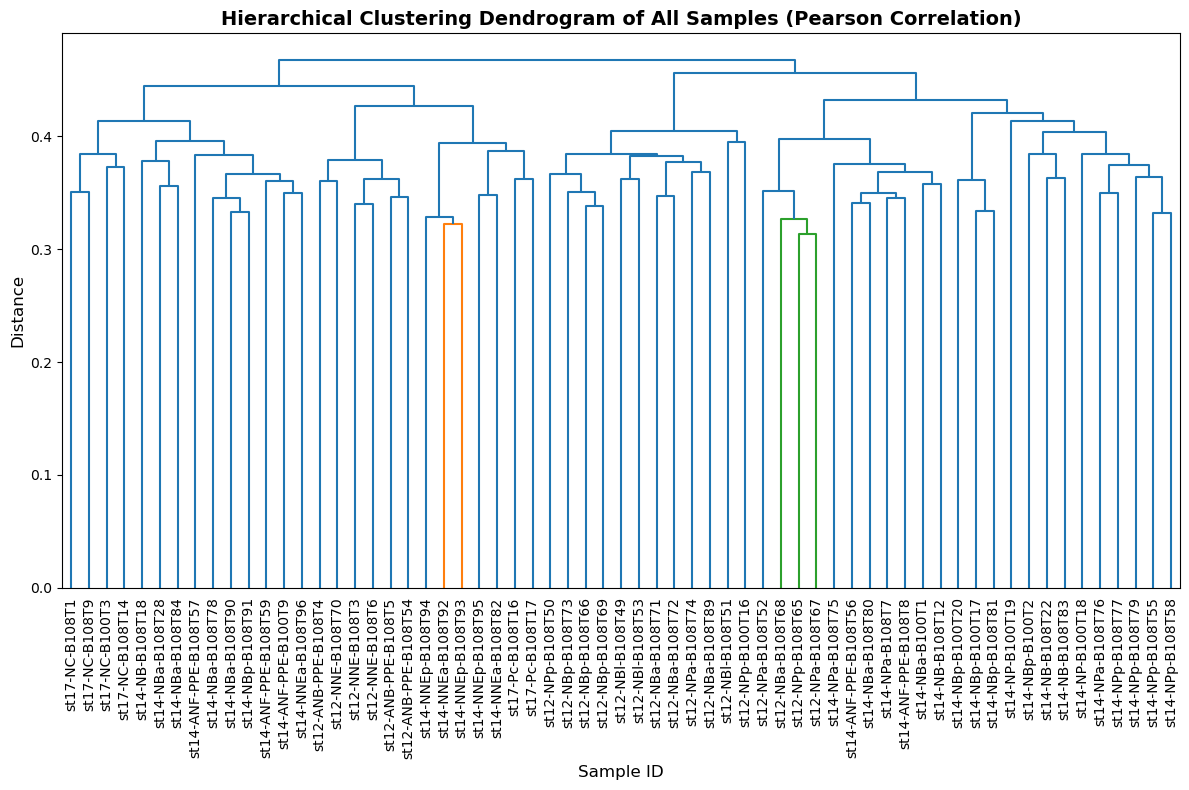

In [ ]:


# DIAGNOSTIC: Check data types and issues
print("=== DATA DIAGNOSTICS ===")
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes.value_counts()}")
print(f"\nFirst few rows:\n{df.head()}")

# Check for non-numeric values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(0)
#df = df[df.mean(axis=1) > 1]
top_var = df.var(axis=1).sort_values(ascending=False).head(100000).index
df = df.loc[top_var]
# Remove all-zero genes
#df = df.loc[df.sum(axis=1) != 0]

# Remove zero-variance genes
df = df.loc[df.std(axis=1) > 0]

print(f"\n=== AFTER CLEANING ===")
print(f"Shape: {df.shape}")
print(f"Data range: [{df.values.min():.3f}, {df.values.max():.3f}]")

# Log transform the data (log2(x+1)) to handle skewness
df_log = np.log2(df + 1)

# Z-score PER GENE (rows), this is fine
df_zscore = df_log.sub(df_log.mean(axis=1), axis=0)
df_zscore = df_zscore.div(df_log.std(axis=1), axis=0)
df_zscore = df_zscore.fillna(0)


df_zscore_T = df_zscore.T

# Method 2: Manual clustering with dendrogram (more control)
df_log_T = df_log.T 

distance_matrix = pdist(df_log_T ,metric='correlation')

# Perform hierarchical clustering
# Common linkage methods: 'ward', 'average', 'complete', 'single'
linkage_matrix = linkage(distance_matrix, method='complete')

# Create the dendrogram
plt.figure(figsize=(12, 8))
dendrogram(
    linkage_matrix,
    labels=df_log_T.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0.7*max(linkage_matrix[:,2])
)

plt.title('Hierarchical Clustering Dendrogram of All Samples (Pearson Correlation)', fontsize=14, fontweight='bold')
plt.xlabel('Sample ID', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.tight_layout()
plt.savefig('dendrogram_merged_100k_pearson.png', dpi=300, bbox_inches='tight')
plt.show()







데이터 로드 완료: 64293 genes x 62 samples
필터링 후: 46469 유전자 사용

설명된 분산:
PC1: 11.12%
PC2: 7.32%

PCA 플롯 저장: pca_plot_merged.png


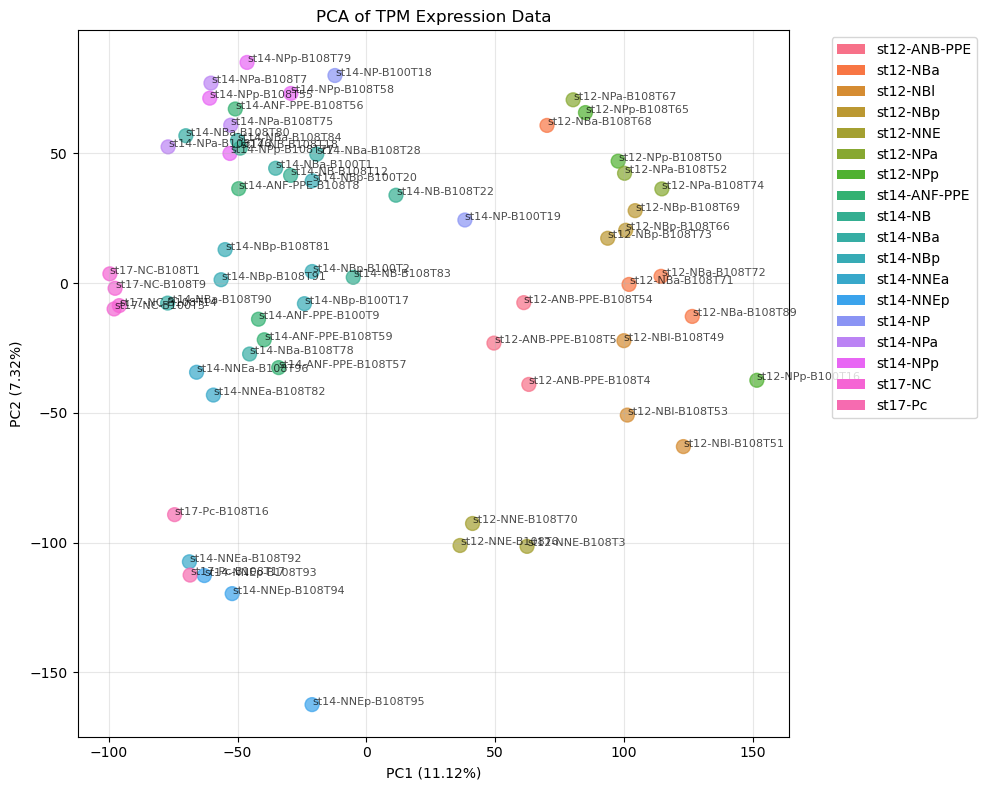

PCA 결과 저장: pca_results.csv


(                         PC1         PC2
 st12-NPp-B108T65   85.085588   65.704076
 st12-NBp-B108T66  100.712092   20.356630
 st12-NBl-B108T49  100.020873  -22.184544
 st12-NNE-B108T3    62.391600 -101.447881
 st12-NPa-B108T67   80.300852   70.625581
 ...                      ...         ...
 st17-NC-B108T1    -99.596903    3.566423
 st17-NC-B108T9    -97.573865   -2.014948
 st17-Pc-B108T16   -74.472214  -89.220618
 st17-Pc-B108T17   -68.441967 -112.516425
 st17-NC-B108T14   -95.940794   -8.678891
 
 [63 rows x 2 columns],
 PCA(n_components=2))

In [36]:
df1 =  pd.read_csv('./DEG/merged_tpm_data_12.csv', index_col=0)
df2 = pd.read_csv('./DEG/merged_tpm_data_14.csv', index_col=0)
df3 = pd.read_csv('./DEG/merged_tpm_data_17.csv', index_col=0)
df = pd.concat([df1, df2,df3], axis=1, join='inner')
def perform_pca_analysis_efficiently(df=df, n_components=2):
    """
    병합된 CSV 파일을 불러와서 PCA 분석 수행 (메모리 효율성 개선)
    """
    # CSV 파일 읽기
    #df = pd.read_csv(csv_file)
    print(f"\n데이터 로드 완료: {df.shape[0]} genes x {df.shape[1]-1} samples")
    
    # Gene ID를 인덱스로 설정 (행: 유전자, 열: 샘플)
    #df = df.set_index('Gene ID')
    
    # 결측치 처리 (0으로 채움)
    df = df.fillna(0)
    
    # *** 효율성 개선 (1/2) ***
    # 전치(transpose)하기 *전에* 유전자 필터링
    # (유전자 x 샘플) 형태에서 유전자 평균 계산 (axis=1)
    gene_means = df.mean(axis=1)
    genes_to_keep = gene_means[gene_means >= 1].index
    df_filtered = df.loc[genes_to_keep]
    print(f"필터링 후: {len(genes_to_keep)} 유전자 사용")

    # 로그 변환 (log2(TPM + 1))
    df_log = np.log2(df_filtered + 1)
    
    # *** 효율성 개선 (2/2) ***
    # 필터링 및 로그 변환이 끝난 *작은* 데이터프레임을 전치
    # (행: 샘플, 열: 유전자)
    df_transposed = df_log.T
    
    # 표준화 (Standardization)
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df_transposed)
    
    # PCA 수행
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(df_scaled)
    
    # 결과를 데이터프레임으로 변환
    pca_df = pd.DataFrame(
        pca_result,
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=df_transposed.index # 인덱스는 샘플명
    )
    
    # 설명된 분산 출력
    print(f"\n설명된 분산:")
    for i, var in enumerate(pca.explained_variance_ratio_):
        print(f"PC{i+1}: {var*100:.2f}%")
    
    # --- 이하 플롯 생성 코드는 원본과 동일 ---
    
    plt.figure(figsize=(10, 8))
    
    # Stage-tissue 정보 추출하여 색상 구분
    sample_info = ['-'.join(s.split('-')[:-1]) for s in pca_df.index]
    unique_groups = sorted(list(set(sample_info))) # 정렬하여 일관된 색상 매핑
    colors = sns.color_palette('husl', n_colors=len(unique_groups))
    color_map = {group: colors[i] for i, group in enumerate(unique_groups)}
    sample_colors = [color_map[info] for info in sample_info]
    
    plt.scatter(pca_df['PC1'], pca_df['PC2'], c=sample_colors, s=100, alpha=0.7)
    
    # 샘플 이름 표시
    for i, sample in enumerate(pca_df.index):
        plt.annotate(sample, (pca_df.loc[sample, 'PC1'], pca_df.loc[sample, 'PC2']), 
                     fontsize=8, alpha=0.7)
    
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
    plt.title('PCA of TPM Expression Data')
    plt.grid(True, alpha=0.3)
    
    # 범례 추가
    legend_elements = [Patch(facecolor=color_map[group], label=group) 
                       for group in unique_groups]
    plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig('pca_plot_merged.png', dpi=300, bbox_inches='tight')
    print(f"\nPCA 플롯 저장: pca_plot_merged.png")
    plt.show()
    
    # PCA 결과 저장
    pca_df.to_csv('pca_results_merged.csv')
    print(f"PCA 결과 저장: pca_results.csv")
    
    return pca_df, pca

perform_pca_analysis_efficiently(df)

In [ ]:
# Log transform the data (log2(x+1)) to handle skewness
df_log = np.log2(df + 1)

# Standardize the data (z-score normalization)
from scipy.stats import zscoreprint(df_ordered.head())
df_zscore = df_log.apply(zscore, axis=1)
df_zscore.head()

GeneID:108704861    [-0.24661016483771617, -0.24661016483771617, -...
GeneID:444335       [-0.5493261866046402, -2.152795131194777, -0.7...
STRG.1              [-0.5239592957944855, -2.1920033930746627, -0....
GeneID:414604       [-0.7182385894696536, -1.7459601414591293, 0.1...
STRG.2              [0.21294256567460887, 0.07481672921045014, 0.3...
dtype: object